In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import warnings
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn import preprocessing
from sklearn import decomposition
import seaborn as sns

# Import des données

In [2]:
playlists = pd.read_csv("playlists.data", sep="\t")
tracks = pd.read_csv("tracks.data", sep="\t")
playlists.head()

,position,title,artists,url,date,playlist
0,1,La marcheuse,Christine and the Queens,https://www.spotontrack.com/track/la-marcheuse...,2018-09-26,fr
1,2,Mojo,Claire Laffut,https://www.spotontrack.com/track/mojo/43473376,2018-09-26,fr
2,3,Julien,Damso,https://www.spotontrack.com/track/julien/41177241,2018-09-26,fr
3,4,Baisers vol\u00e9s,The Pirouettes,https://www.spotontrack.com/track/baisers-vole...,2018-09-26,fr
4,5,\u00c0 la folie - Rework,Juliette Armanet,https://www.spotontrack.com/track/a-la-folie-r...,2018-09-26,fr


# 0 : Prétraitements

In [3]:
#set date format
playlists["date"] = pd.to_datetime(playlists["date"], format="%Y-%m-%d")

#change encoding
playlists["title"] = playlists["title"].str.encode("ascii").str.decode("unicode-escape")
playlists["artists"] = playlists["artists"].str.encode("ascii").str.decode("unicode-escape")

#several artists become several lines
tmp = playlists.artists.str.split(",").apply(pd.Series)
tmp.index = [playlists.position, playlists.title, playlists.url, playlists.date, playlists.playlist]
tmp = tmp.stack().reset_index()
tmp.drop("level_5", axis=1, inplace=True)
playlists = tmp.rename(index=str, columns={0 : "artists"})

#change Mode to numerical
tracks["Mode"] = tracks["Mode"].apply(lambda x: 0 if x == "Minor" else 1)

print((playlists[["title","artists"]][playlists["title"] == "L'aérogramme de Los Angeles"]).head())

                           title        artists
11   L'aérogramme de Los Angeles        Woodkid
12   L'aérogramme de Los Angeles   Louis Garrel
359  L'aérogramme de Los Angeles        Woodkid
360  L'aérogramme de Los Angeles   Louis Garrel
440  L'aérogramme de Los Angeles        Woodkid


# Variables utiles

In [16]:
# Nom des playlists
playlist_names = playlists["playlist"].unique()
# Nombre de chansons par playlist
playlist_nb = {elem: playlists[playlists["playlist"] == elem].shape[0] for elem in playlist_names}

#variables numériques et catégoriques
variables = tracks.columns.tolist()
variables.remove("url")
categorical_variables = ["Key"]
num_variables = [i for i in variables if i not in categorical_variables]

# dataframes avec l'url en tant qu'indice
playlists_index = playlists.set_index("url")
tracks_index = tracks.set_index("url")

# 2.1.1 : Préparation des données


In [5]:
#position pic
pic_position = playlists.reset_index().groupby(by=["url", "playlist"], sort=False, as_index=False, group_keys=False).agg({"position":'min'})
pic_position.rename(columns = {"position":"pic_position"}, inplace=True)

#indicateur binaire top position
pic_position["binary_15"] = (pic_position["pic_position"] <= 15)*1

#Durée en nombre de semaines
nb_weeks = playlists.groupby(by=["url", "playlist"], sort=False, as_index=False).agg({"date": lambda x: x.dt.week.unique().shape[0]})
nb_weeks.rename(columns = {"date":"nb_weeks"}, inplace=True)

#Position moyenne
mean_weeks = playlists.groupby(by=["url", "playlist"], sort=False, as_index=False).agg({"position": 'mean'})
mean_weeks.rename(columns = {"position":"mean_position"}, inplace=True)

#indicateur binaire position moyenne
mean_weeks["binary_15_mean"] = (mean_weeks["mean_position"] <= 15)*1

# 2.1.2 : Analyse exploratoire
## 1D

/home/lucas/.local/lib/python3.6/site-packages/pandas/plotting/_core.py:2251: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared
  return_type=return_type, **kwds)


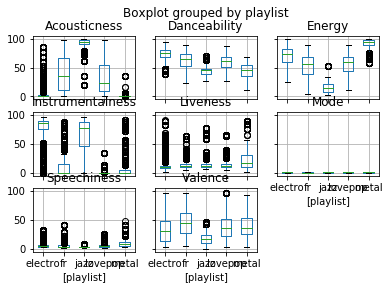

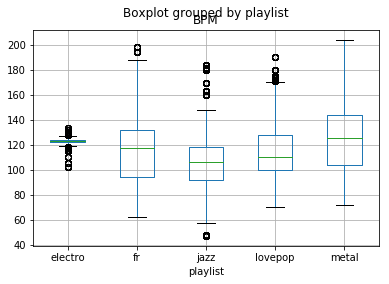

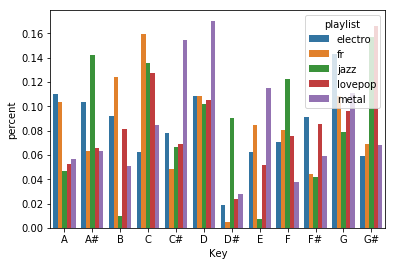

,playlist,Key,number,title,url,date,artists,BPM,Mode,Danceability,Valence,Energy,Acousticness,Instrumentalness,Liveness,Speechiness,percent
0,electro,A,1123,1123,1123,1123,1123,1123,1123,1123,1123,1123,1123,1123,1123,1123,0.110120
1,electro,A#,1056,1056,1056,1056,1056,1056,1056,1056,1056,1056,1056,1056,1056,1056,0.103550
2,electro,B,942,942,942,942,942,942,942,942,942,942,942,942,942,942,0.092371
3,electro,C,640,640,640,640,640,640,640,640,640,640,640,640,640,640,0.062757
4,electro,C#,794,794,794,794,794,794,794,794,794,794,794,794,794,794,0.077858
5,electro,D,1107,1107,1107,1107,1107,1107,1107,1107,1107,1107,1107,1107,1107,1107,0.108551
6,electro,D#,194,194,194,194,194,194,194,194,194,194,194,194,194,194,0.019023
7,electro,E,635,635,635,635,635,635,635,635,635,635,635,635,635,635,0.062267
8,electro,F,719,719,719,719,719,719,719,719,719,719,719,719,719,719,0.070504
9,electro,F#,926,926,926,926,926,926,926,926,926,926,926,926,926,926,0.090802


In [24]:
##### Traitements à faire sur ce df, car sinon on ne prend pas la fréquence
playlists_tracks = pd.merge(playlists, tracks, on="url")

# Boxplots
playlist_names = playlists["playlist"].unique()
all_columns_but_bpm = [i for i in playlists_tracks.columns.tolist() if i != "BPM" and (i in tracks.columns.tolist() or i == "playlist")]
fig, ax = plt.subplots()
playlists_tracks[all_columns_but_bpm].boxplot(by="playlist", figsize=(10,10), ax=ax)
fig.suptitle("Boxplot grouped by playlist", y=1)

playlists_tracks.boxplot(column="BPM", by="playlist")
plt.show()

# On divise ici par le nombre de chansons du type de la playlist pour avoir un pourcentage et non un simple comptage.
tmp = playlists_tracks.groupby(by=["playlist", "Key"]).count().reset_index()
tmp.rename(columns={"position" : "number"}, inplace=True)
tmp["percent"] = tmp.apply(lambda x: x.number / playlist_nb[x.playlist], axis=1)
sns.barplot(x=tmp.Key, y=tmp.percent, hue=tmp.playlist)
plt.show()

On remarque plusieurs faits de cette première analyse :
- La variable instrumentalness est très discriminante : elle se répartit différemment pour chacune des playlists.
- La variable speechiness est au contraire peu intéressante, présentant des valeurs similaires pour toutes les playlists.
- L'histogramme sur les clés nous montre que jazz a souvent plus 
- BPM : Les chansons de techno sont centrées sur 126 avec un écart-type très faible.

L'analyse 1D des variables se continue dans la partie 2D, la diagonale de la matrice de corrélation nous présentant leur distribution.

## 2D

,position,BPM,Mode,Danceability,Valence,Energy,Acousticness,Instrumentalness,Liveness,Speechiness
position,1.000000,-0.037607,0.028857,-0.062657,-0.101319,-0.073480,0.063680,0.184729,-0.034734,0.018328
BPM,-0.037607,1.000000,-0.031578,0.042761,0.130745,0.341925,-0.296713,-0.053662,0.026493,0.216438
Mode,0.028857,-0.031578,1.000000,-0.048029,-0.126324,-0.110648,0.114424,0.038861,-0.073488,-0.063320
Danceability,-0.062657,0.042761,-0.048029,1.000000,0.372122,0.348905,-0.492339,0.131389,-0.128266,0.021983
Valence,-0.101319,0.130745,-0.126324,0.372122,1.000000,0.442180,-0.388866,-0.297967,-0.009324,0.129291
Energy,-0.073480,0.341925,-0.110648,0.348905,0.442180,1.000000,-0.892547,-0.281800,0.097678,0.363876
Acousticness,0.063680,-0.296713,0.114424,-0.492339,-0.388866,-0.892547,1.000000,0.183155,-0.018227,-0.317126
Instrumentalness,0.184729,-0.053662,0.038861,0.131389,-0.297967,-0.281800,0.183155,1.000000,-0.120334,-0.211447
Liveness,-0.034734,0.026493,-0.073488,-0.128266,-0.009324,0.097678,-0.018227,-0.120334,1.000000,0.076463
Speechiness,0.018328,0.216438,-0.063320,0.021983,0.129291,0.363876,-0.317126,-0.211447,0.076463,1.000000


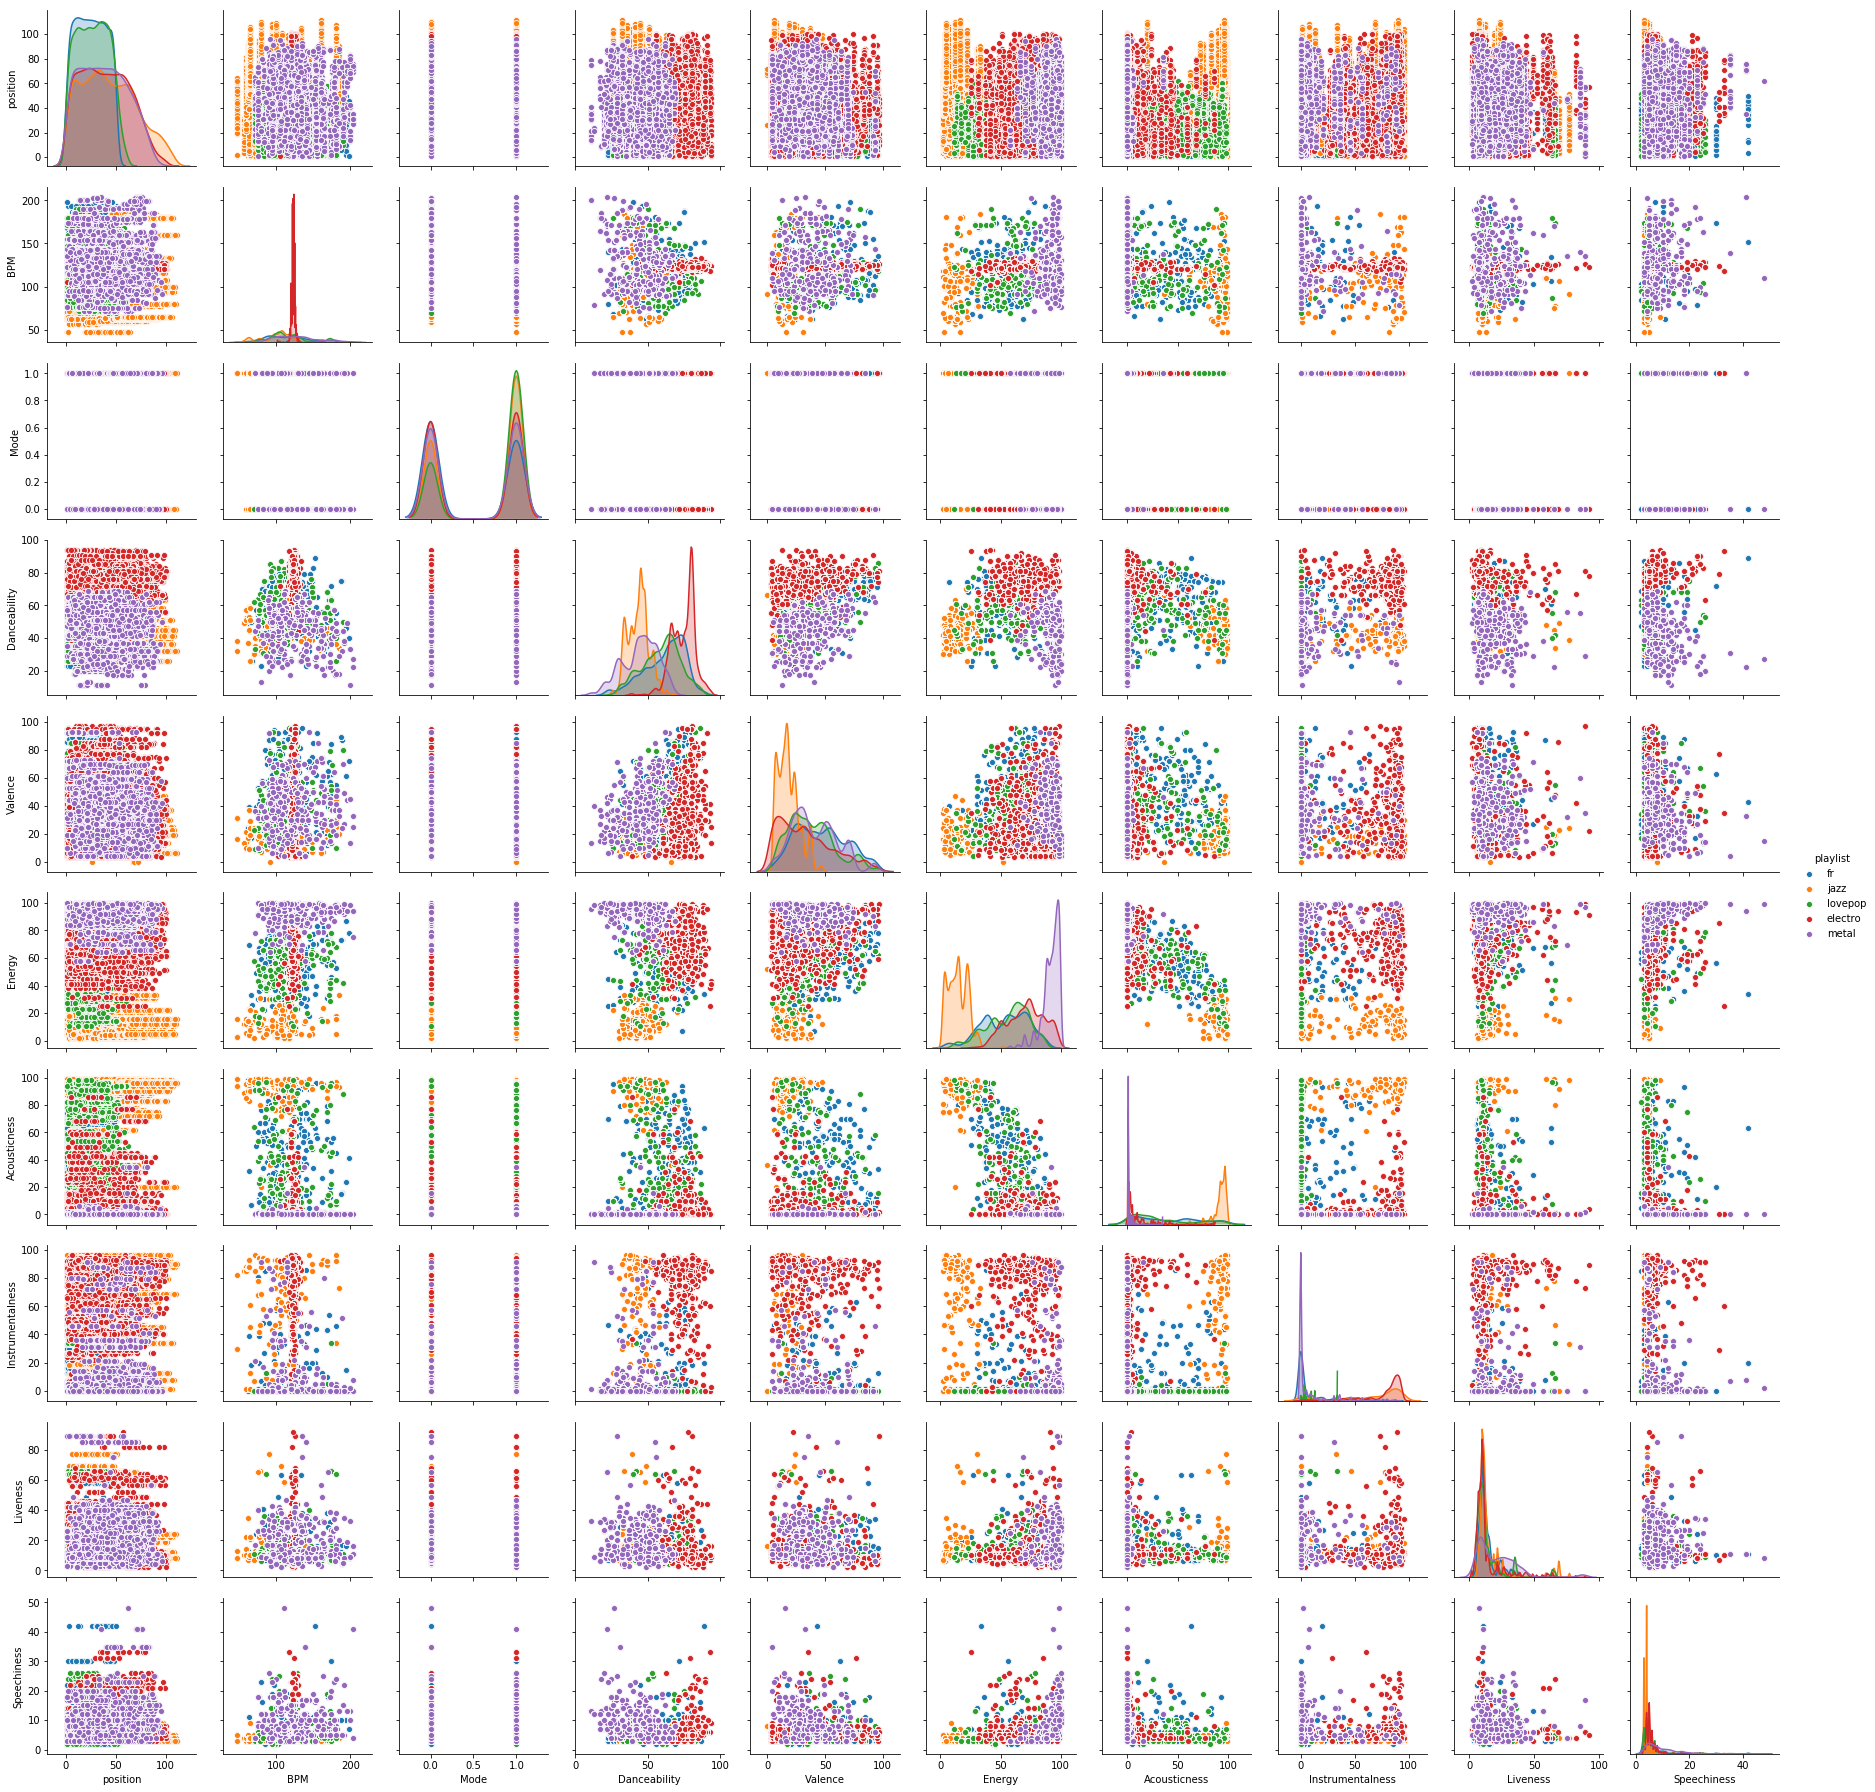

In [14]:
corr = playlists_tracks.corr()
sns.pairplot(playlists_tracks, hue="playlist")
corr
# Valeurs intéressantes : accousticness-energy et valence-energy

### Suite de l'analyse 1D:

- Certaines variables présentent des distributions discriminantes selon la playlist: energy pour metal et jazz, accousticness pour les mêmes playlists.

De toutes les observations en 1D on peut conclure que les playlists les plus faciles à expliquer seront sûrement metal et jazz, car elles possèdent des valeurs uniques sur certaines features.

### Analyse 2D :

On remarque peu de corrélations prononcées dans les données. Les exceptions à cette répartition homogène sont accousticness-energy et valence-energy.

## Chanson moyenne

In [12]:
tracks_playlist = tracks_index.join(playlists_index["playlist"])
mean_songs = tracks_playlist.groupby(by="playlist").mean()

#no care : just need playlist now that mean is computed
tracks_playlist_unique = tracks_playlist[~tracks_playlist.duplicated(keep="first")]

#On considère que le plus proche est celui qui minimise les écarts au carré
for playlist_name in playlist_names:
    mean_song = mean_songs.loc[playlist_name][num_variables]
    playlist_songs = tracks_playlist_unique[tracks_playlist_unique["playlist"] == playlist_name][num_variables]
    diff = (playlist_songs.sub(mean_song, axis=1)**2).sum(axis=1)
    print("5 Chansons les plus proches pour le style {} : {}".format(playlist_name, diff.nsmallest(5).index.tolist()))


mean_songs

5 Chansons les plus proches pour le style fr : ['https://www.spotontrack.com/track/au-sud-de-la-banlieue-nord/6957880', 'https://www.spotontrack.com/track/mojo/43473376', 'https://www.spotontrack.com/track/ailleurs-higher/31565565', 'https://www.spotontrack.com/track/les-filles-d-aujourd-hui-brigitte-fontaine/39759852', 'https://www.spotontrack.com/track/sequences/25510622']
5 Chansons les plus proches pour le style jazz : ['https://www.spotontrack.com/track/after-all/35226975', 'https://www.spotontrack.com/track/vid-froso-kyrka-at-froso-church-from-frosoblomster-froso-flowers-arr-j-ekberg-p-v-johansson-and-l-simonsson/658319', 'https://www.spotontrack.com/track/good-morning-goodbye/730546', 'https://www.spotontrack.com/track/infant-eyes/42081448', 'https://www.spotontrack.com/track/i-got-it-bad/7121622']
5 Chansons les plus proches pour le style lovepop : ['https://www.spotontrack.com/track/imagine/46379076', 'https://www.spotontrack.com/track/i-ll-be-there/31901506', 'https://www.spo

,BPM,Danceability,Valence,Energy,Acousticness,Instrumentalness,Liveness,Speechiness
playlist,,,,,,,,
electro,123.024122,74.779859,33.949696,70.947539,4.344381,77.308688,14.023730,5.989410
fr,116.641433,61.955047,46.956955,53.860263,41.439355,10.804071,14.456743,5.916879
jazz,105.336889,43.762459,18.370440,14.548290,91.364739,63.940228,16.366368,3.934772
lovepop,116.911495,59.489149,38.480841,56.164971,34.324517,0.624449,14.419973,5.431163
metal,127.482495,44.998471,40.676196,91.955664,0.306528,8.049534,21.316924,8.992662


## Chanson mieux classée par playlist

In [13]:
mean_weeks_title = playlists.groupby(by=["url", "playlist"], sort=False, as_index=False).agg({"position": 'mean', "title" : "min"})
for playlist in playlist_names:
    tmp = mean_weeks_title[mean_weeks["playlist"] == playlist]
    best_song = tmp.loc[tmp["position"].idxmin()]
    print("Playlist {}, best average position : {} Song : {} / {}".format(playlist, best_song["position"], best_song["title"], best_song["url"]))


Playlist fr, best average position : 3.0 Song : Coco Câline / https://www.spotontrack.com/track/coco-caline/20833855
Playlist jazz, best average position : 1.0 Song : Infant Eyes / https://www.spotontrack.com/track/infant-eyes/42081448
Playlist lovepop, best average position : 1.0 Song : imagine / https://www.spotontrack.com/track/imagine/46379076
Playlist electro, best average position : 3.0 Song : Purple Noise / https://www.spotontrack.com/track/purple-noise/1039522
Playlist metal, best average position : 1.0 Song : Psychosocial / https://www.spotontrack.com/track/psychosocial/46085512


## Artiste mieux classé par playlist


In [21]:
mean_weeks_artist = playlists.groupby(by=["playlist", "artists"], sort=False, as_index=False).agg({"position": 'mean'})
for playlist in playlist_names:
    tmp = mean_weeks_artist[mean_weeks_artist["playlist"] == playlist]
    best_artist = tmp.loc[tmp["position"].idxmin()]["artists"]
    print("Best artist on average for {} : {}".format(playlist, best_artist))



Best artist on average for fr : Grand Corps Malade
Best artist on average for jazz : Fred Hersch Trio
Best artist on average for lovepop :  Sia
Best artist on average for electro : Adana Twins
Best artist on average for metal : Rage Against The Machine


## Évolution temporelle 10 variables

var BPM, min 62, max 198


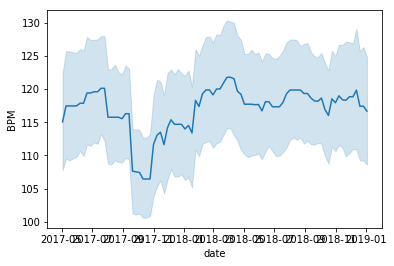

var Mode, min 0, max 1


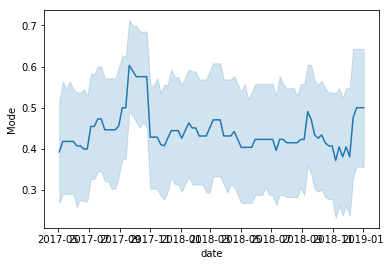

var Danceability, min 23, max 89


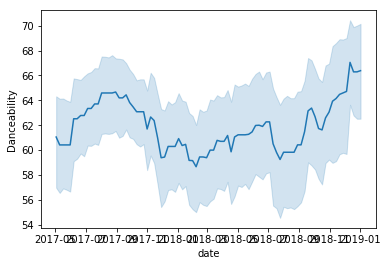

var Valence, min 5, max 96


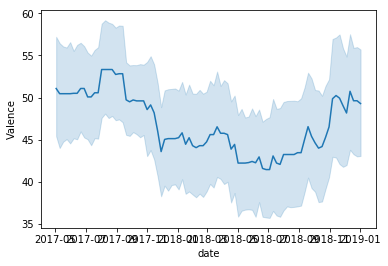

var Energy, min 5, max 89


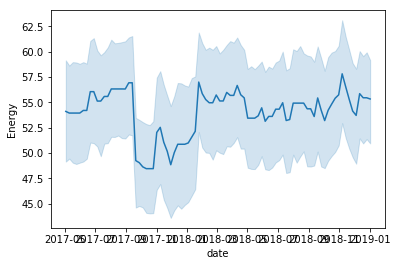

var Acousticness, min 0, max 98


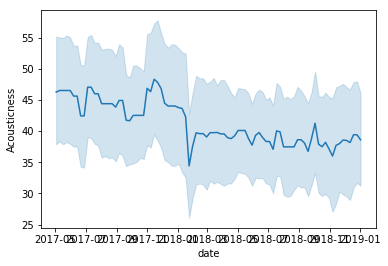

var Instrumentalness, min 0, max 88


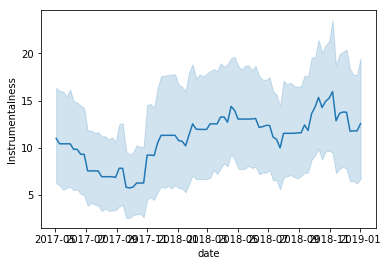

var Liveness, min 4, max 63


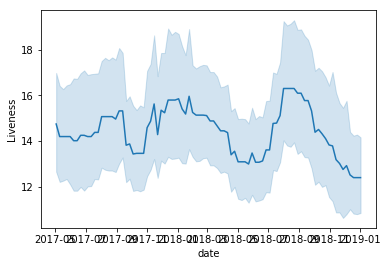

var Speechiness, min 2, max 42


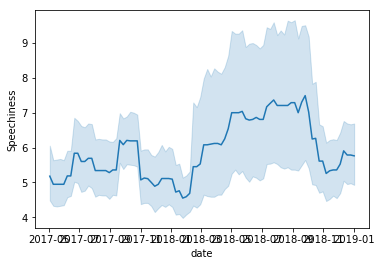

{'BPM': 136,
 'Mode': 1,
 'Danceability': 66,
 'Valence': 91,
 'Energy': 84,
 'Acousticness': 98,
 'Instrumentalness': 88,
 'Liveness': 59,
 'Speechiness': 40}

In [28]:
pl = "fr"
tracks_playlist_temp = tracks_index.join(playlists_index[["playlist", "date"]])
tracks_playlist_temp = tracks_playlist_temp[tracks_playlist_temp["playlist"] == pl]
tracks_playlist_temp.groupby("date").mean()
val_ranges = {}
for variable in num_variables:
    sns.lineplot(data=tracks_playlist_temp, x="date", y=variable)
    min_val = tracks_playlist_temp[variable].min()
    max_val = tracks_playlist_temp[variable].max()
    print("var {}, min {}, max {}".format(variable, min_val, max_val))
    val_ranges[variable] = max_val - min_val
    plt.show()
val_ranges

In [29]:
tracks_playlist_temp

,BPM,Key,Mode,Danceability,Valence,Energy,Acousticness,Instrumentalness,Liveness,Speechiness,playlist,date
url,,,,,,,,,,,,
https://www.spotontrack.com/track/1982/10343045,82,F#,0,58,25,38,34,48,11,3,fr,2017-06-14
https://www.spotontrack.com/track/1982/10343045,82,F#,0,58,25,38,34,48,11,3,fr,2017-06-28
https://www.spotontrack.com/track/1982/10343045,82,F#,0,58,25,38,34,48,11,3,fr,2017-07-26
https://www.spotontrack.com/track/1982/10343045,82,F#,0,58,25,38,34,48,11,3,fr,2017-08-09
https://www.spotontrack.com/track/1982/10343045,82,F#,0,58,25,38,34,48,11,3,fr,2017-06-21
https://www.spotontrack.com/track/1982/10343045,82,F#,0,58,25,38,34,48,11,3,fr,2017-07-12
https://www.spotontrack.com/track/1982/10343045,82,F#,0,58,25,38,34,48,11,3,fr,2017-08-23
https://www.spotontrack.com/track/1982/10343045,82,F#,0,58,25,38,34,48,11,3,fr,2017-07-05
https://www.spotontrack.com/track/1982/10343045,82,F#,0,58,25,38,34,48,11,3,fr,2017-07-19


## Évolution temporelle taille

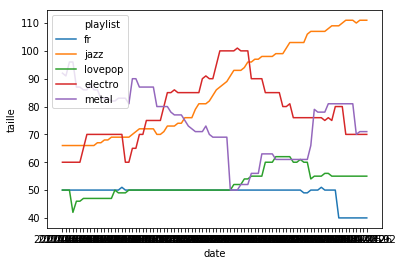

In [34]:
#groupby count + sélection
nb_semaines = playlists.groupby(by=["playlist", "date"], sort=False, as_index=False).count()[["playlist", "date", "index"]].rename(columns={"index" : "taille"})
sns.lineplot(data=nb_semaines, x="date", y="taille", hue="playlist")

#  2.1.3 Analyse exploratoire multidimensionnelle

In [59]:
# On commence par normaliser les données et ne sélectionner que les données numériques
tracks_scaled = (tracks[num_variables] - tracks[num_variables].mean())/tracks[num_variables].std()
print(tracks.mean())
print(tracks.std())
print(tracks.head())
tracks_scaled.head()

BPM                 120.192110
Danceability         61.076329
Valence              36.471698
Energy               65.041166
Acousticness         22.904803
Instrumentalness     38.197256
Liveness             15.609777
Speechiness           6.494854
dtype: float64
BPM                 23.667275
Danceability        17.037706
Valence             22.053205
Energy              25.737567
Acousticness        32.970092
Instrumentalness    39.654307
Liveness            12.423688
Speechiness          4.736079
dtype: float64
                                                 url  BPM Key   Mode  \
0    https://www.spotontrack.com/track/eres/42205629  127  C#  Major   
1  https://www.spotontrack.com/track/rise-dirty-d...  120   C  Major   
2  https://www.spotontrack.com/track/hipcats/3809...  122   C  Major   
3  https://www.spotontrack.com/track/the-review/4...  122   G  Major   
4     https://www.spotontrack.com/track/dre/41836600  123  A#  Minor   

   Danceability  Valence  Energy  Acousticness  I

,BPM,Danceability,Valence,Energy,Acousticness,Instrumentalness,Liveness,Speechiness
0,0.287650,1.110694,1.883096,-0.234722,-0.694715,1.180269,-0.612522,-0.315631
1,-0.008117,1.169387,1.157578,0.231523,-0.694715,1.255923,-0.773504,-0.104486
2,0.076388,1.580240,2.200510,1.280573,-0.694715,-0.862384,-1.095470,-0.104486
3,0.076388,1.110694,-0.429493,0.037254,-0.512731,1.180269,-0.693013,-0.104486
4,0.118640,0.699840,-0.429493,0.386938,-0.694715,1.230705,-0.773504,-0.526776


[0.74909011 0.96734436 0.98875393 1.         1.        ]
(1166, 8)


(1166, 5)

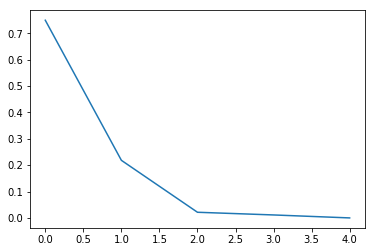

In [56]:
# On applique l'ACP
pca = decomposition.PCA()
pca.fit(tracks_scaled.head())
sns.lineplot(data=pca.explained_variance_ratio_)
print(np.cumsum(pca.explained_variance_ratio_))
x_pca = pca.transform(tracks_scaled)
print(tracks_scaled.shape)
x_pca.shape